# Introduction to AutoGen: Credit Risk Assessment Workflow

This workflow follows a realistic credit-risk process:

- Document verification for registration and GST evidence
- Compliance checks such as MCA and sanctions review
- Financial analysis using the latest available year data
- Credit bureau review when score or rating data is available
- Industry-risk classification using the provided matrix
- Final risk assessment using a 100-point scorecard covering Compliance (20), Liquidity (20), Leverage (15), Profitability (15), External Credit Bureau (15), and Industry Risk (15)

The final score is used to determine the applicable risk category, credit limit, and payment terms according to the provided assessment rules.

## Install dependencies


In [1]:
%pip install -qU autogen "autogen-agentchat" "autogen-ext[openai,azure]"

Note: you may need to restart the kernel to use updated packages.


### Initialising Azure OpenAI client to invoke the LLM


In [2]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
from autogen_core.models import UserMessage

Please fill in `api_key="<replace_your_api_key>"` by replacing `<replace_your_api_key>` with your actual API key.

> The Azure configuration values already provided for `azure_deployment`, `model`, `api_version`, and `azure_endpoint` can stay as they are for this lab.


In [ ]:
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

az_model_client = AzureOpenAIChatCompletionClient(
    azure_deployment="gpt-5.4-mini",
    model="gpt-5.4-mini",
    api_version="2025-01-01-preview",
    azure_endpoint="https://hakunamatata11.openai.azure.com/",
    api_key="<replace_your_api_key_here>",
    model_info={
        "vision": True,
        "function_calling": True,
        "json_output": True,
        "family": "unknown",
        "structured_output": True,
    },
)

print("Azure OpenAI model client ready")

Azure OpenAI model client ready


## Logging


In [4]:
import logging

from autogen_core import EVENT_LOGGER_NAME

# Configure the root logger so events are visible when debugging agent behavior.
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(EVENT_LOGGER_NAME)
logger.addHandler(logging.StreamHandler())
logger.setLevel(logging.INFO)


AutoGen uses the standard Python logging module to emit events such as model calls, tool executions, and responses. Logging is useful because it helps you understand what an agent is doing behind the scenes while debugging or monitoring a workflow. In practice, it shows when the model is called, when tools are invoked, and how the agent is progressing through a task.


## Message System


AutoGen agents communicate through messages. In this credit-risk workflow, messages carry details such as company documents, compliance status, financial ratios, and assessment decisions. This message-based approach is important because each component of the workflow can share structured information in a controlled and traceable way.

Messages generally fall into two categories:

- Agent-to-agent messages: text, media, and structured payloads
- Internal events: tool calls, status updates, and workflow notifications


### Agent-Agent Messages

Agent-to-agent messages inherit from `BaseChatMessage`. The most common examples are:

- `TextMessage` for plain text
- `MultiModalMessage` for document or image content


In [5]:
from autogen_agentchat.messages import TextMessage

# A basic text message represents a user request or a message passed between agents.
text_message = TextMessage(
    content="Review the credit-risk application for Apex Manufacturing Pvt Ltd.",
    source="relationship_manager",
)
text_message


TextMessage(id='b58e51a1-9b43-42dd-a196-551db47f2699', source='relationship_manager', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 9, 29, 7, 16, 22, 437911, tzinfo=datetime.timezone.utc), content='Review the credit-risk application for Apex Manufacturing Pvt Ltd.', type='TextMessage')

### Multi Modal messages



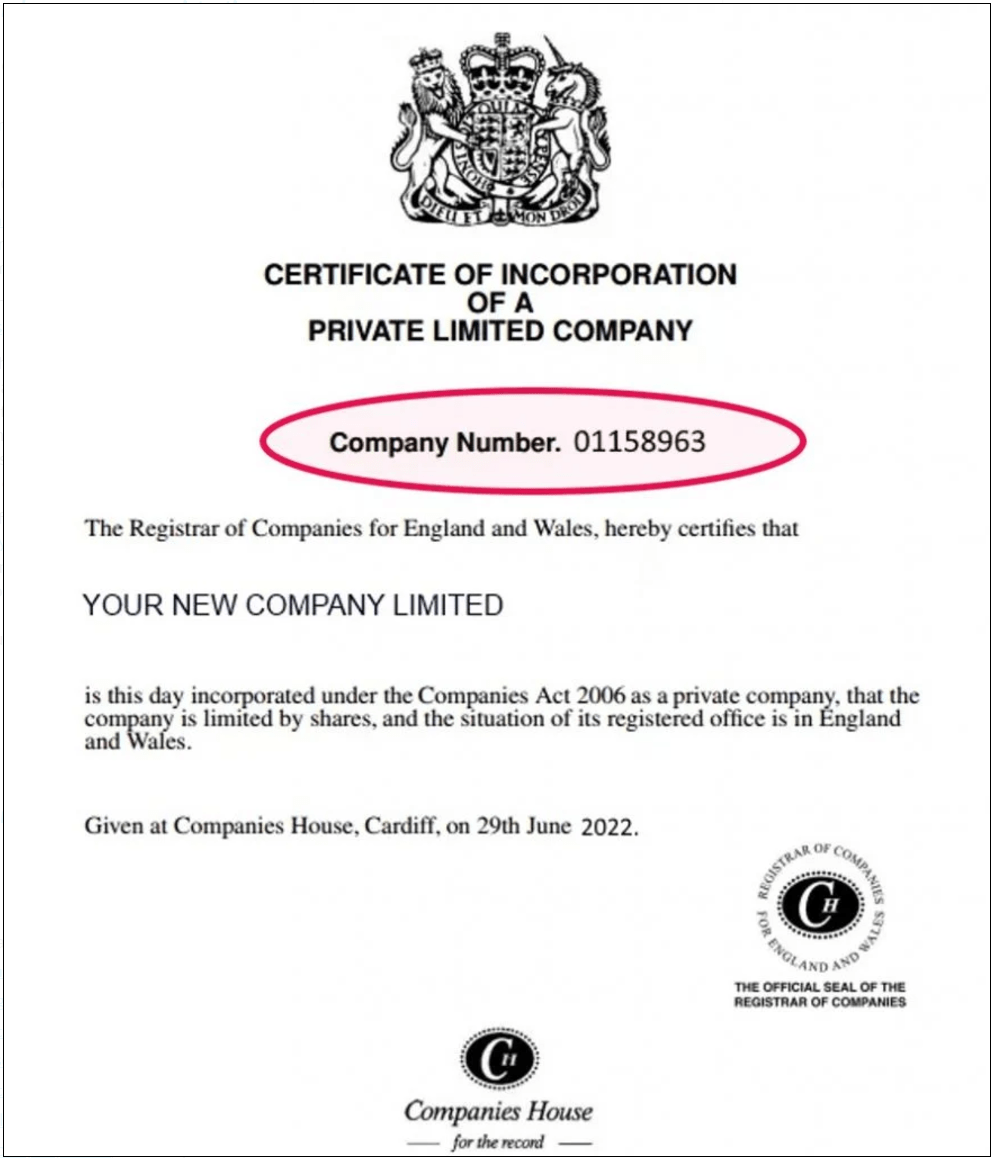

In [6]:
from PIL import Image
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image as AGImage

# Load the sample company registration document.
pil_image = Image.open("../../media/company_registration_certificate.png")
img = AGImage(pil_image)

multi_modal_message = MultiModalMessage(
    content=[
        "Review the company registration document and identify the company name shown in the document.",
        img,
    ],
    source="credit_ops",
)

img

# Test the multimodal agent 
By providing the company registration certificate image and asking the agent to identify the company name and company number.

{"tools": [], "type": "LLMCall", "messages": [{"content": "You are a credit-risk document verification agent. Review the provided company registration document and identify the company name and company number visible in the document.", "role": "system"}, {"role": "user", "name": "credit_ops", "content": [{"type": "text", "text": "Review the company registration document and identify the company name shown in the document."}, {"type": "image_url", "image_url": {"url": "", "detail": "auto"}}]}], "response": {"id": "chatcmpl-ETMMcyLR76ispHEUQCdeKfEmv8zx4", "choices": [{"finish_reason": "stop", "index": 0, "logprobs": null, "message": {"content": "The company name shown in the document is **YOUR NEW COMPANY LIMITED**.", "refusal": null, "role": "assistant", "annotations": [], "audio": null, "function_call": null, "tool_calls": null}, "content_filter_results": {"hate": {"filtered": false, "severity": "safe"}, "protected_material_code": {"detected": false, "filtered": false}, "protected_mate
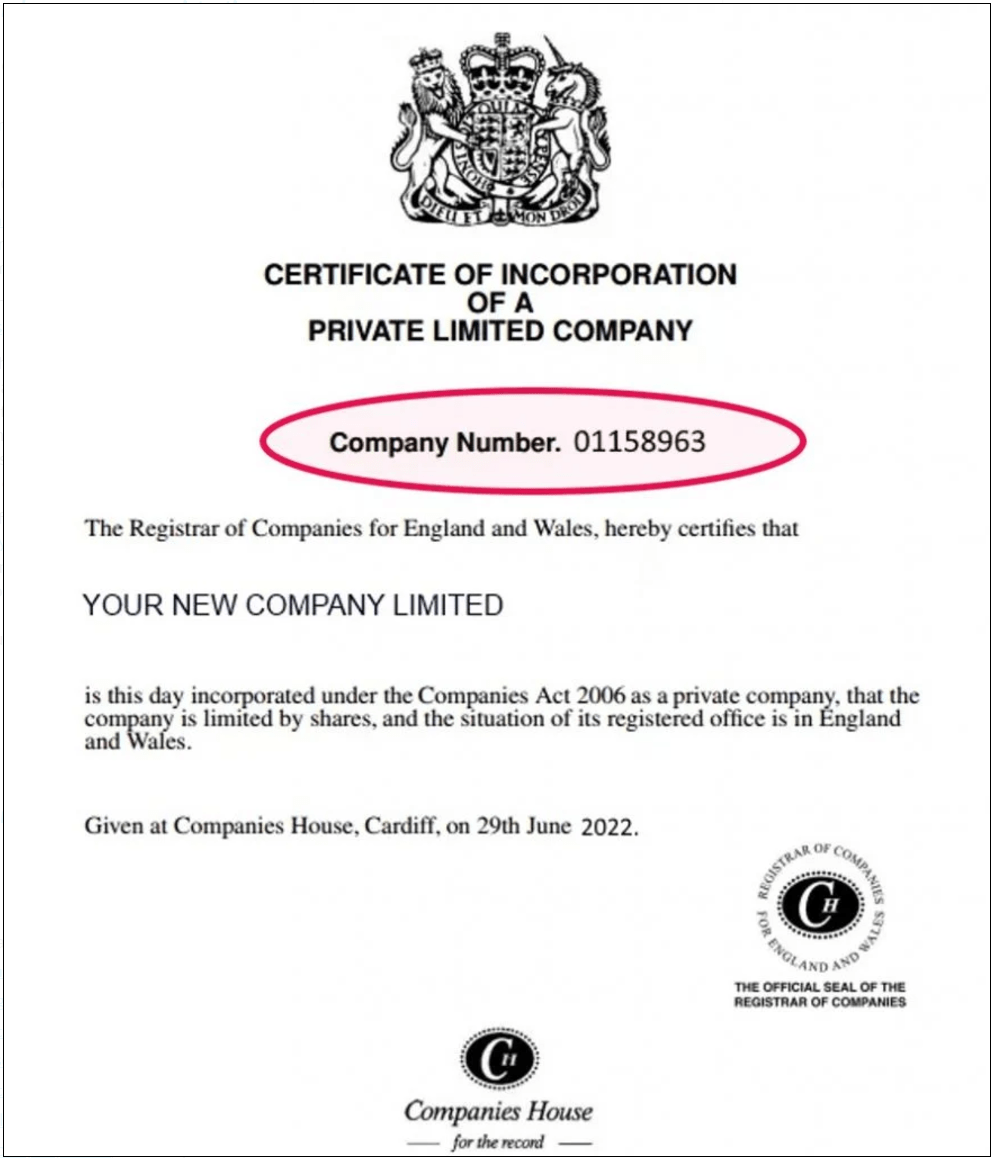
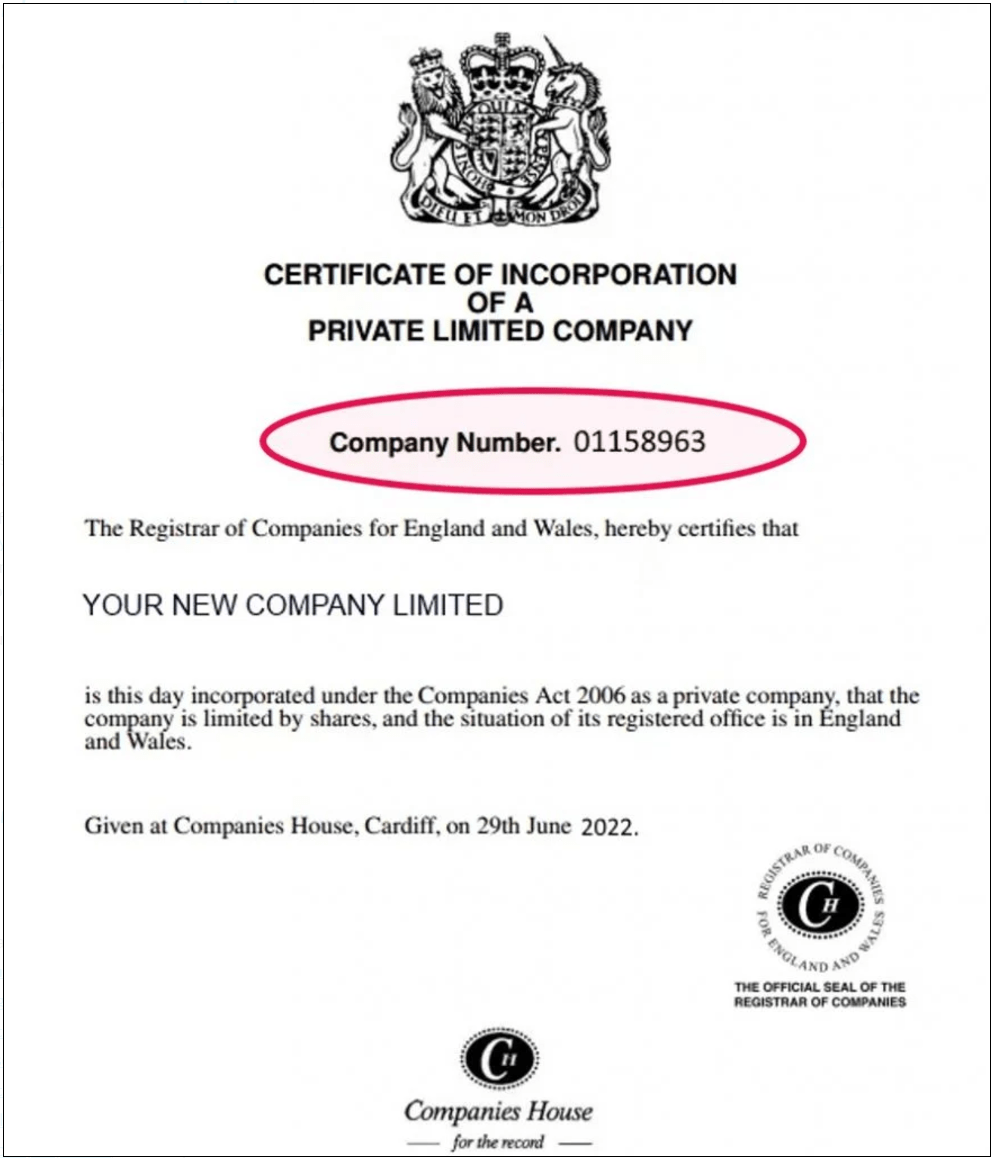

The company name shown in the document is **YOUR NEW COMPANY LIMITED**.


c:\Users\UdaySomapuram\AppData\Local\Programs\Python\Python312\Lib\site-packages\autogen_agentchat\agents\_assistant_agent.py:1109: UserWarning: Resolved model mismatch: gpt-5.4-mini != gpt-5.4-mini-2026-03-17. Model mapping in autogen_ext.models.openai may be incorrect. Set the model to gpt-5.4-mini-2026-03-17 to enhance token/cost estimation and suppress this warning.
  model_result = await model_client.create(


In [7]:
from autogen_agentchat.agents import AssistantAgent

multimodal_agent = AssistantAgent(
    name="document_verification_agent",
    model_client=az_model_client,
    system_message=(
        "You are a credit-risk document verification agent. "
        "Review the provided company registration document and identify "
        "the company name and company number visible in the document."
    ),
    model_client_stream=False,
)

result = await multimodal_agent.run(task=multi_modal_message)

print(result.messages[-1].content)

### Subclasses in messages

Why and when to subclass?

AutoGen provides abstract base classes for both message exchange and internal workflow events. Subclassing is useful when you want to attach structured business data, override the text representation, or pass additional metadata to a user interface or monitoring layer. For example, in a credit-risk workflow, a custom message can carry document status, sanctions flags, and scoring information in a structured format.


Imports & helper models


In [8]:
from __future__ import annotations

from typing import Any, Dict
from pydantic import BaseModel
from autogen_agentchat.messages import (
    BaseChatMessage,
    BaseAgentEvent,
)
from autogen_core.models import UserMessage

### Custom Chat Message (`CreditRiskContextMessage`)

This message carries structured credit-risk context such as company name, document status, and compliance notes.


In [9]:
class CreditRiskContextMessage(BaseChatMessage):
    """
    A message that carries structured data for a credit-risk application.
    This is useful when different agents need to pass business context in a consistent format.
    """

    content: Dict[str, Any]

    def to_text(self) -> str:
        return f"[Credit Risk Context] {self.content}"

    def to_model_text(self) -> str:
        return str(self.content)

    def to_model_message(self) -> UserMessage:
        return UserMessage(content=self.to_model_text(), source=self.source)


### Custom Internal Event (`RiskAlertEvent`)

This event represents a workflow alert such as a missing document or a compliance exception.


In [10]:
class RiskAlertEvent(BaseAgentEvent):
    """
    An internal event signalling that a credit-risk validation issue was raised.
    This is useful for alerts, warnings, or operational signals that should not be sent directly to the model.
    """

    level: str
    details: str

    def to_text(self) -> str:
        return f"[{self.level}] {self.details}"


### Minimal Demo with a Credit Risk Analyst Agent

This example shows how a single `AssistantAgent` can review a credit application, check documents, and produce a structured result.


In [11]:
pip install nest-asyncio

Note: you may need to restart the kernel to use updated packages.


In [12]:
from autogen_core import CancellationToken
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import TextMessage
import nest_asyncio

nest_asyncio.apply()

async def verify_document_pack(company_name: str, registration_certificate: str, gst_certificate: str) -> str:
    """Check whether the required company documents are available and whether the names match."""
    if not registration_certificate or not gst_certificate:
        return "Missing required documents: registration certificate and/or GST certificate."
    if company_name.lower() not in registration_certificate.lower() or company_name.lower() not in gst_certificate.lower():
        return "Company name mismatch across documents."
    return "Documents available and company names match."

credit_risk_agent = AssistantAgent(
    name="credit_risk_analyst",
    model_client=az_model_client,
    tools=[verify_document_pack],
    system_message="You are the credit risk analyst. Review the validation request and clearly flag missing documents or name mismatches.",
    reflect_on_tool_use=True,
    model_client_stream=False,
)

async def run_credit_risk_demo():
    token = CancellationToken()
    response = await credit_risk_agent.on_messages(
        [TextMessage(content="Check the document pack for Apex Manufacturing Pvt Ltd. Registration certificate is available and names match. GST certificate is missing.", source="relationship_manager")],
        cancellation_token=token,
    )
    print(response.chat_message.content)

await run_credit_risk_demo()

{"tools": [{"type": "function", "function": {"name": "verify_document_pack", "description": "Check whether the required company documents are available and whether the names match.", "parameters": {"type": "object", "properties": {"company_name": {"description": "company_name", "title": "Company Name", "type": "string"}, "registration_certificate": {"description": "registration_certificate", "title": "Registration Certificate", "type": "string"}, "gst_certificate": {"description": "gst_certificate", "title": "Gst Certificate", "type": "string"}}, "required": ["company_name", "registration_certificate", "gst_certificate"], "additionalProperties": false}, "strict": false}}], "type": "LLMCall", "messages": [{"content": "You are the credit risk analyst. Review the validation request and clearly flag missing documents or name mismatches.", "role": "system"}, {"role": "user", "name": "relationship_manager", "content": "Check the document pack for Apex Manufacturing Pvt Ltd. Registration cert

**Validation review for Apex Manufacturing Pvt Ltd**

- **Registration certificate:** Available
- **GST certificate:** **Missing**
- **Name consistency:** **Mismatch flagged across documents**

Please obtain the missing GST certificate and reconcile the company name exactly as it appears on all submitted documents before proceeding.


c:\Users\UdaySomapuram\AppData\Local\Programs\Python\Python312\Lib\site-packages\autogen_agentchat\agents\_assistant_agent.py:1450: UserWarning: Resolved model mismatch: gpt-5.4-mini != gpt-5.4-mini-2026-03-17. Model mapping in autogen_ext.models.openai may be incorrect. Set the model to gpt-5.4-mini-2026-03-17 to enhance token/cost estimation and suppress this warning.
  reflection_result = await model_client.create(


With these patterns, you can build structured, auditable interactions for a real credit-risk workflow. This design helps keep the process organized, explainable, and easier to extend as the business logic grows.


## Understanding agents


AutoGen AgentChat includes built-in agents designed for different tasks. In a credit-risk workflow, the same principles apply: each agent preserves state, accepts messages, and may use tools to perform structured checks.

`name`: A unique identifier for the agent.

`description`: A summary of the agent’s role.

`run(task)`: Executes the agent on a new task and returns a `TaskResult`.

`run_stream(task)`: Returns an asynchronous stream of messages, useful for processing status updates.

These agents rely on the message classes from `autogen_agentchat.messages`.


In [13]:
async def get_compliance_status(company_name: str, mca_status: str | None = None, sanctions_status: str | None = None, adverse_record_status: str | None = None) -> str:
    """Return the current compliance status and clearly mark unavailable checks."""
    status_parts = [f"Company: {company_name}"]
    if mca_status is None:
        status_parts.append("MCA status unavailable.")
    else:
        status_parts.append(f"MCA status: {mca_status}")
    if sanctions_status is None:
        status_parts.append("Sanctions check unavailable.")
    else:
        status_parts.append(f"Sanctions check: {sanctions_status}")
    if adverse_record_status is None:
        status_parts.append("Adverse record check unavailable.")
    else:
        status_parts.append(f"Adverse record check: {adverse_record_status}")
    return "; ".join(status_parts)

# This helper computes a few core financial indicators that are commonly used in credit review.
async def calculate_financial_ratios(
    current_assets: float,
    current_liabilities: float,
    total_debt: float,
    total_equity: float,
    revenue: float,
    net_income: float,
) -> str:
    """Compute key financial ratios for the latest financial year."""
    current_ratio = (
        current_assets / current_liabilities
        if current_liabilities
        else None
    )
    debt_to_equity = (
        total_debt / total_equity
        if total_equity
        else None
    )
    net_profit_margin = (
        (net_income / revenue) * 100
        if revenue
        else None
    )

    current_ratio_text = f"{current_ratio:.2f}" if current_ratio is not None else "N/A"
    debt_to_equity_text = f"{debt_to_equity:.2f}" if debt_to_equity is not None else "N/A"
    net_profit_margin_text = f"{net_profit_margin:.2f}%" if net_profit_margin is not None else "N/A"

    return (
        f"Current Ratio={current_ratio_text}, "
        f"Debt-to-Equity={debt_to_equity_text}, "
        f"Net Profit Margin={net_profit_margin_text}"
    )

# This function represents external bureau information, which may be missing in some applications.
async def get_credit_bureau_summary(score: str | None = None, rating: str | None = None) -> str:
    """Return bureau information if available; otherwise flag it as missing."""
    if score is None and rating is None:
        return "External credit bureau information unavailable."
    return f"Bureau score={score}, bureau rating={rating}"

In [14]:
credit_analyst = AssistantAgent(
    name="credit_analyst",
    model_client=az_model_client,
    tools=[get_compliance_status, calculate_financial_ratios, get_credit_bureau_summary],
    system_message="You are a credit-risk analyst responsible for interpreting company documents, compliance signals, financial ratios, and bureau information.",
    reflect_on_tool_use=True,
    model_client_stream=False,
)

Getting responses
We can use the `run()` method to execute a credit-risk assessment request. When you call `run()`, the method returns a `TaskResult` object with a `messages` attribute that captures the agent's reasoning and final reply.

The important part is that the agent stores internal context between runs. For a credit-risk workflow, that means you should pass only the new request or a focused summary instead of resending the entire assessment history each time.

`run()` → `TaskResult` → `messages` list shows the workflow steps and final answer.


In [15]:
async def assess_credit_application() -> None:
    result = await credit_analyst.run(
        task=(
            "Assess the credit-risk application for Apex Manufacturing Pvt Ltd "
            "using the following latest financial-year data from 2025:\n\n"
            "Current Assets: 7,800,000\n"
            "Current Liabilities: 5,000,000\n"
            "Total Debt: 9,300,000\n"
            "Shareholders' Equity: 5,000,000\n"
            "Revenue: 9,000,000\n"
            "Net Profit: 500,000\n"
            "External Credit Bureau Score: 720\n"
            "Industry: Manufacturing\n\n"
            "Calculate the Current Ratio, Debt-to-Equity, and Net Profit Margin "
            "using the available financial data. "
            "Apply the provided credit-risk scorecard and clearly show the "
            "calculated ratios and available score components. "
            "Do not invent unavailable compliance, MCA, sanctions, or document information."
        )
    )
    print(result.messages[-1].content)

await assess_credit_application()

{"tools": [{"type": "function", "function": {"name": "get_compliance_status", "description": "Return the current compliance status and clearly mark unavailable checks.", "parameters": {"type": "object", "properties": {"company_name": {"description": "company_name", "title": "Company Name", "type": "string"}, "mca_status": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "mca_status", "title": "Mca Status"}, "sanctions_status": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "sanctions_status", "title": "Sanctions Status"}, "adverse_record_status": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "adverse_record_status", "title": "Adverse Record Status"}}, "required": ["company_name"], "additionalProperties": false}, "strict": false}}, {"type": "function", "function": {"name": "calculate_financial_ratios", "description": "Compute key financial ratios for the latest financial year.", "para

Here is the credit-risk assessment for **Apex Manufacturing Pvt Ltd** based only on the data you provided.

## 1) Calculated Financial Ratios

### Current Ratio
**Formula:** Current Assets / Current Liabilities  
**Calculation:** 7,800,000 / 5,000,000 = **1.56**

**Interpretation:**  
A current ratio of **1.56** indicates moderate short-term liquidity. The company has **₹1.56 of current assets for every ₹1 of current liabilities**, which is generally acceptable, though not particularly strong.

---

### Debt-to-Equity Ratio
**Formula:** Total Debt / Shareholders' Equity  
**Calculation:** 9,300,000 / 5,000,000 = **1.86**

**Interpretation:**  
A debt-to-equity ratio of **1.86** suggests the business is moderately leveraged. This means debt is **1.86 times equity**, which may indicate some balance-sheet pressure depending on industry norms and cash flow stability.

---

### Net Profit Margin
**Formula:** Net Profit / Revenue  
**Calculation:** 500,000 / 9,000,000 = **5.56%**

**Interpre

### Multi-Modal Input
The `AssistantAgent` can also review a certificate image as part of a document verification workflow.


{"tools": [], "type": "LLMCall", "messages": [{"content": "You are a document verification agent. Check the certificate for company name consistency and identify the registration status shown in the document.", "role": "system"}, {"role": "user", "name": "credit_ops", "content": [{"type": "text", "text": "Review this certificate image and tell me whether the company name and registration status look valid for a credit application."}, {"type": "image_url", "image_url": {"url": "", "detail": "auto"}}]}], "response": {"id": "chatcmpl-ETMMpAfVvIPKKZtIr8gezHbYPC9HG", "choices": [{"finish_reason": "stop", "index": 0, "logprobs": null, "message": {"content": "The certificate shows:\n\n- **Company name:** **YOUR NEW COMPANY LIMITED**\n- **Registration status/type:** It says the company **\u201cis this day incorporated\u201d** under the Companies Act 2006 as a **private company limited by shares**.\n- **Company number:** **01158963**\n- **Jurisdiction:** **England and Wales**\n\n**Consistency c
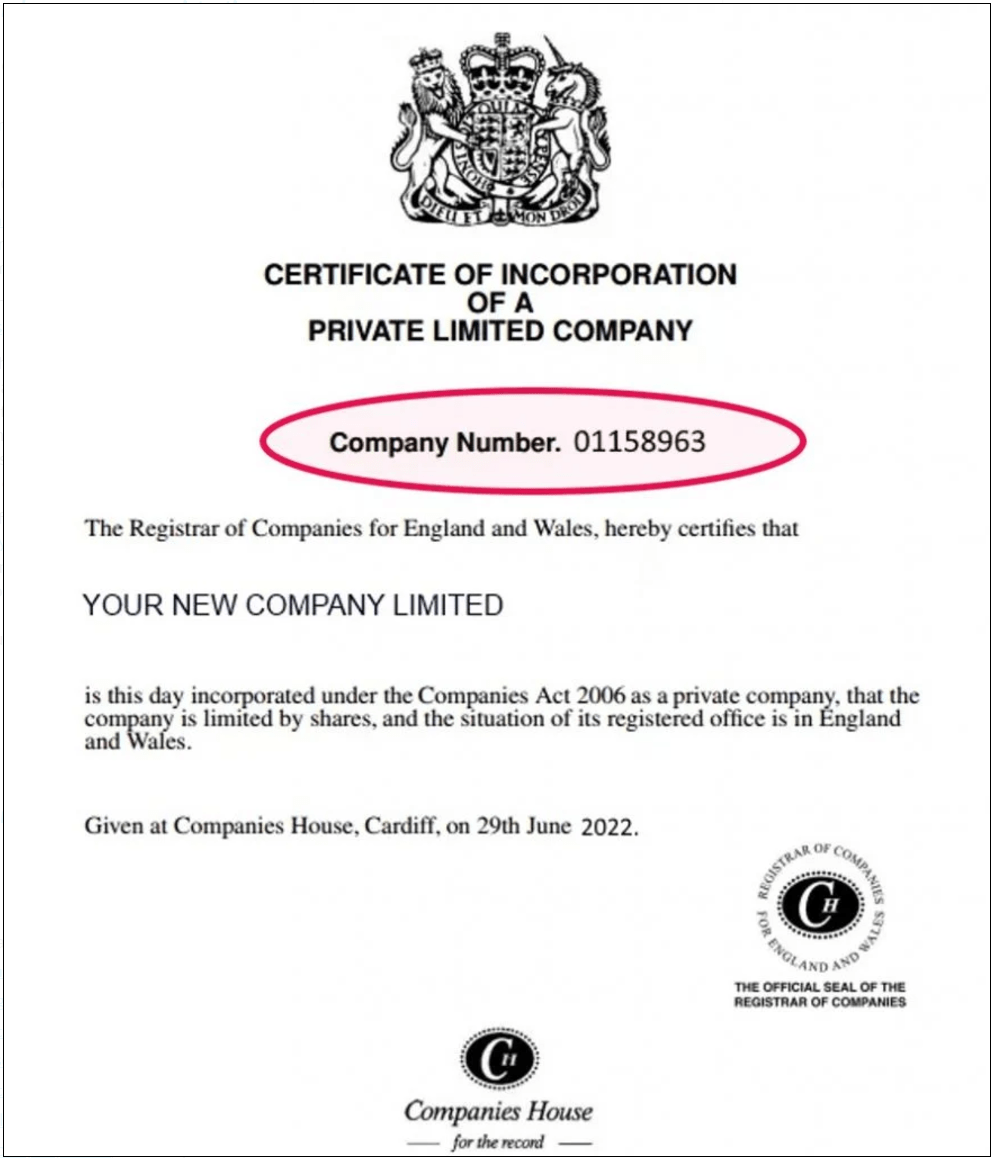
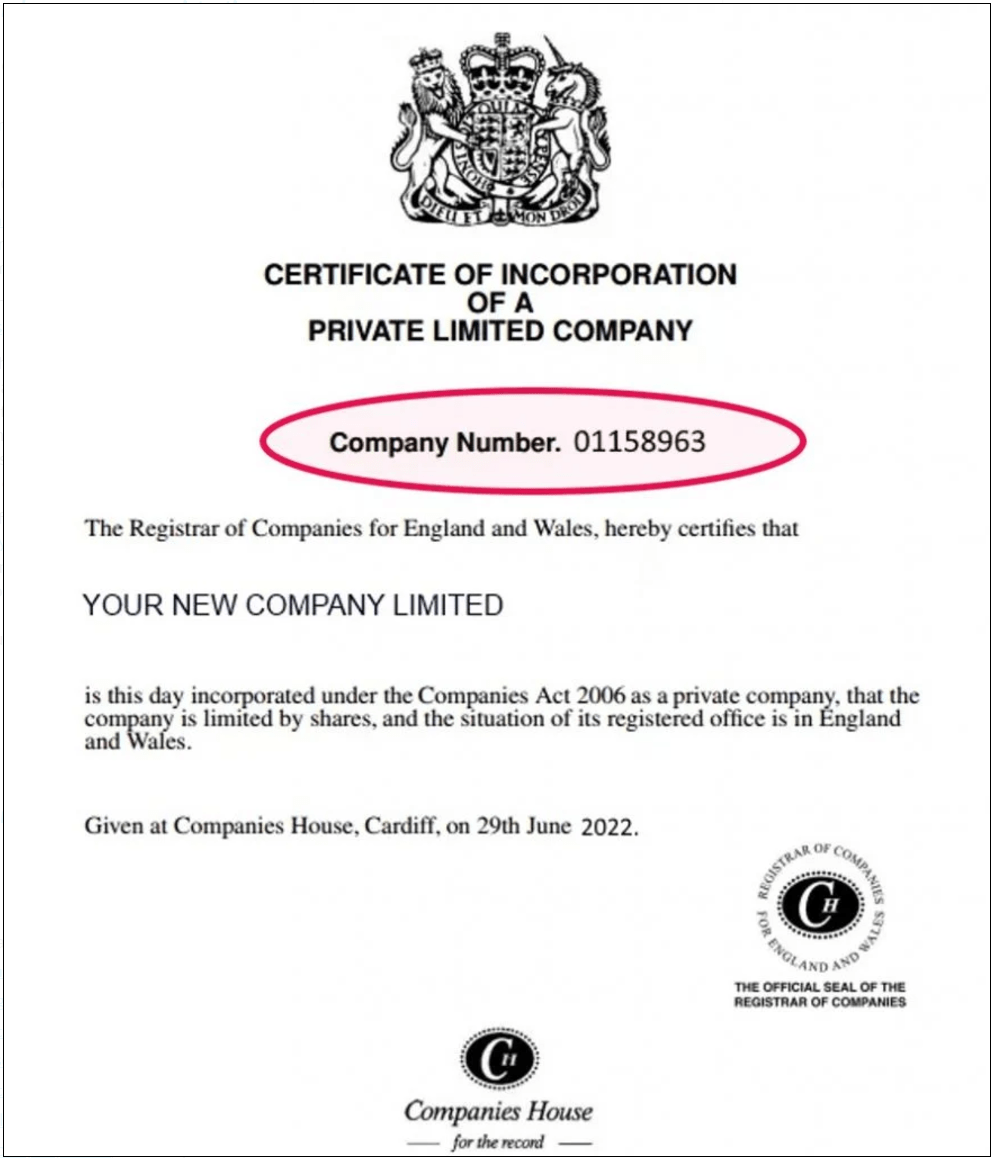

The certificate shows:

- **Company name:** **YOUR NEW COMPANY LIMITED**
- **Registration status/type:** It says the company **“is this day incorporated”** under the Companies Act 2006 as a **private company limited by shares**.
- **Company number:** **01158963**
- **Jurisdiction:** **England and Wales**

**Consistency check:**  
The company name appears consistent within the document. The registration status shown is **incorporated / private limited company**, which is a valid registration type on the face of the certificate.

**Credit-application note:**  
From the image alone, it looks like a genuine-style incorporation certificate, but I can’t independently verify with Companies House from the image itself. If you want, I can also help you identify any **red flags** on the document.


In [16]:
from PIL import Image
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image as AGImage

# Load the sample company registration document
pil_image = Image.open("../../media/company_registration_certificate.png")
img = AGImage(pil_image)

multimodal_message = MultiModalMessage(
    content=[
        "Review this certificate image and tell me whether the company name and registration status look valid for a credit application.",
        img,
    ],
    source="credit_ops",
)

img

multimodal_agent = AssistantAgent(
    name="document_verification_agent",
    model_client=az_model_client,
    system_message=(
        "You are a document verification agent. "
        "Check the certificate for company name consistency "
        "and identify the registration status shown in the document."
    ),
    reflect_on_tool_use=False,
    model_client_stream=False,
)

result = await multimodal_agent.run(task=multimodal_message)

print(result.messages[-1].content)

### Streaming Messages

The `run_stream()` method allows a credit-risk workflow to emit updates as each stage is processed. This is especially useful when a workflow is checking documents, compliance, financials, and bureau data in sequence.

It returns an asynchronous generator. In this demo, the Model client is kept non-streaming to avoid the Azure preview issue while preserving the same AutoGen pattern and workflow logic.


In [17]:
from autogen_agentchat.messages import TextMessage

streaming_agent = AssistantAgent(
    name="risk_streaming_assistant",
    model_client=az_model_client,
    system_message="You are a credit-risk workflow assistant. Report status updates as the document, compliance, financial, and bureau checks proceed.",
    model_client_stream=False,
)

async def credit_stream_task():
    print("\nCredit-risk workflow output:\n")
    async for msg in streaming_agent.run_stream(task="Perform a full credit-risk review for Apex Manufacturing Pvt Ltd and report processing steps."):
        if hasattr(msg, "type") and hasattr(msg, "content"):
            print(f"{msg.type}: {msg.content}")
        elif isinstance(msg, TextMessage):
            print(f"TextMessage: {msg.content}")
        else:
            print(f"[TaskResult] Task completed with {len(msg.messages)} messages.")

await credit_stream_task()


Credit-risk workflow output:

TextMessage: Perform a full credit-risk review for Apex Manufacturing Pvt Ltd and report processing steps.


{"tools": [], "type": "LLMCall", "messages": [{"content": "You are a credit-risk workflow assistant. Report status updates as the document, compliance, financial, and bureau checks proceed.", "role": "system"}, {"role": "user", "name": "user", "content": "Perform a full credit-risk review for Apex Manufacturing Pvt Ltd and report processing steps."}], "response": {"id": "chatcmpl-ETMMrOaGyX4mhuXf6okC6J0CyzHQz", "choices": [{"finish_reason": "stop", "index": 0, "logprobs": null, "message": {"content": "I can help with the credit-risk review workflow, but I don\u2019t have access to Apex Manufacturing Pvt Ltd\u2019s internal documents, bank data, or credit bureau records from here.\n\n### What I can do now\nI can perform a structured **credit-risk review framework** and track the processing steps if you provide the relevant inputs.\n\n### Processing steps for a full credit-risk review\n1. **Document check**\n   - Legal entity details\n   - Audited financial statements\n   - GST / VAT / t

TextMessage: I can help with the credit-risk review workflow, but I don’t have access to Apex Manufacturing Pvt Ltd’s internal documents, bank data, or credit bureau records from here.

### What I can do now
I can perform a structured **credit-risk review framework** and track the processing steps if you provide the relevant inputs.

### Processing steps for a full credit-risk review
1. **Document check**
   - Legal entity details
   - Audited financial statements
   - GST / VAT / tax filings
   - Bank statements
   - Management information
   - Existing loan/credit facilities
   - KYC/ownership documents

2. **Compliance check**
   - Company registration validity
   - Director / shareholder verification
   - AML / sanctions screening
   - Litigation / insolvency checks
   - Regulatory filings consistency

3. **Financial analysis**
   - Revenue trend
   - EBITDA / operating margin
   - Leverage and debt service capacity
   - Liquidity ratios
   - Cash flow stability
   - Working capita

## Using tools with agents


### Why Add Tools to LLMs?

Credit-risk reviews need more than language generation. They need deterministic checks for:

* legal document verification
* compliance lookups
* ratio calculations
* bureau score retrieval
* industry-risk classification

Tool calling lets the LLM request structured outputs from deterministic logic and then reason over them safely.


### FunctionTool: Turning a Python Function into a Credit-Risk Tool

Any `async` Python function with type hints and a clear docstring can be registered as an AutoGen tool. In a credit-risk workflow, this is ideal for deterministic checks and financial calculations.


In [18]:
from autogen_core.tools import FunctionTool

async def document_lookup(company_name: str) -> str:
    """Return the latest document status for a company."""
    return f"Document check for {company_name}: Company Registration Certificate present; GST Certificate present; company name matches."

credit_document_tool = FunctionTool(document_lookup, description="Check whether required documents are present and valid for a credit application.")
credit_document_tool.schema

{'name': 'document_lookup',
 'description': 'Check whether required documents are present and valid for a credit application.',
 'parameters': {'type': 'object',
  'properties': {'company_name': {'description': 'company_name',
    'title': 'Company Name',
    'type': 'string'}},
  'required': ['company_name'],
  'additionalProperties': False},
 'strict': False}

### AssistantAgent + Reflection

`AssistantAgent` is a good fit for a credit-risk analyst because it can use tools and then explain the result in plain English without exposing the implementation details.


In [19]:
nest_asyncio.apply()

credit_assistant = AssistantAgent(
    name="credit_assistant",
    model_client=az_model_client,
    tools=[document_lookup, get_compliance_status, calculate_financial_ratios],
    system_message="Use the available tools to assess the credit application. Clearly note missing information and show the calculations used.",
    reflect_on_tool_use=True,
    model_client_stream=False,
)

async def run_credit_assistant_demo():
    await Console(
        credit_assistant.run_stream(
            task="Assess the credit-risk file for Apex Manufacturing Pvt Ltd using document, compliance, and financial inputs."
        )
    )

await run_credit_assistant_demo()

---------- TextMessage (user) ----------
Assess the credit-risk file for Apex Manufacturing Pvt Ltd using document, compliance, and financial inputs.


{"tools": [{"type": "function", "function": {"name": "document_lookup", "description": "Return the latest document status for a company.", "parameters": {"type": "object", "properties": {"company_name": {"description": "company_name", "title": "Company Name", "type": "string"}}, "required": ["company_name"], "additionalProperties": false}, "strict": false}}, {"type": "function", "function": {"name": "get_compliance_status", "description": "Return the current compliance status and clearly mark unavailable checks.", "parameters": {"type": "object", "properties": {"company_name": {"description": "company_name", "title": "Company Name", "type": "string"}, "mca_status": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "mca_status", "title": "Mca Status"}, "sanctions_status": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "sanctions_status", "title": "Sanctions Status"}, "adverse_record_status": {"anyOf": [{"type": "string"}

---------- ToolCallRequestEvent (credit_assistant) ----------
[FunctionCall(id='call_oSONCCTq6C7AgOZgqaiTtNmR', arguments='{"company_name": "Apex Manufacturing Pvt Ltd"}', name='document_lookup'), FunctionCall(id='call_V7V4uoMaNrxYDnFwW9hVxKZT', arguments='{"company_name": "Apex Manufacturing Pvt Ltd"}', name='get_compliance_status'), FunctionCall(id='call_sLkaX6niKEe9sNoxgdfQSuJs', arguments='{"current_assets": 0, "current_liabilities": 0, "total_debt": 0, "total_equity": 0, "revenue": 0, "net_income": 0}', name='calculate_financial_ratios')]


{"type": "ToolCall", "tool_name": "document_lookup", "arguments": {"company_name": "Apex Manufacturing Pvt Ltd"}, "result": "Document check for Apex Manufacturing Pvt Ltd: Company Registration Certificate present; GST Certificate present; company name matches.", "agent_id": null}
INFO:autogen_core.events:{"type": "ToolCall", "tool_name": "document_lookup", "arguments": {"company_name": "Apex Manufacturing Pvt Ltd"}, "result": "Document check for Apex Manufacturing Pvt Ltd: Company Registration Certificate present; GST Certificate present; company name matches.", "agent_id": null}
{"type": "ToolCall", "tool_name": "get_compliance_status", "arguments": {"company_name": "Apex Manufacturing Pvt Ltd"}, "result": "Company: Apex Manufacturing Pvt Ltd; MCA status unavailable.; Sanctions check unavailable.; Adverse record check unavailable.", "agent_id": null}
INFO:autogen_core.events:{"type": "ToolCall", "tool_name": "get_compliance_status", "arguments": {"company_name": "Apex Manufacturing Pv

---------- ToolCallExecutionEvent (credit_assistant) ----------
[FunctionExecutionResult(content='Document check for Apex Manufacturing Pvt Ltd: Company Registration Certificate present; GST Certificate present; company name matches.', name='document_lookup', call_id='call_oSONCCTq6C7AgOZgqaiTtNmR', is_error=False), FunctionExecutionResult(content='Company: Apex Manufacturing Pvt Ltd; MCA status unavailable.; Sanctions check unavailable.; Adverse record check unavailable.', name='get_compliance_status', call_id='call_V7V4uoMaNrxYDnFwW9hVxKZT', is_error=False), FunctionExecutionResult(content='Current Ratio=N/A, Debt-to-Equity=N/A, Net Profit Margin=N/A', name='calculate_financial_ratios', call_id='call_sLkaX6niKEe9sNoxgdfQSuJs', is_error=False)]


{"tools": [], "type": "LLMCall", "messages": [{"content": "Use the available tools to assess the credit application. Clearly note missing information and show the calculations used.", "role": "system"}, {"role": "user", "name": "user", "content": "Assess the credit-risk file for Apex Manufacturing Pvt Ltd using document, compliance, and financial inputs."}, {"role": "assistant", "tool_calls": [{"id": "call_oSONCCTq6C7AgOZgqaiTtNmR", "function": {"arguments": "{\"company_name\": \"Apex Manufacturing Pvt Ltd\"}", "name": "document_lookup"}, "type": "function"}, {"id": "call_V7V4uoMaNrxYDnFwW9hVxKZT", "function": {"arguments": "{\"company_name\": \"Apex Manufacturing Pvt Ltd\"}", "name": "get_compliance_status"}, "type": "function"}, {"id": "call_sLkaX6niKEe9sNoxgdfQSuJs", "function": {"arguments": "{\"current_assets\": 0, \"current_liabilities\": 0, \"total_debt\": 0, \"total_equity\": 0, \"revenue\": 0, \"net_income\": 0}", "name": "calculate_financial_ratios"}, "type": "function"}], "c

---------- TextMessage (credit_assistant) ----------
Here’s the credit-risk assessment for **Apex Manufacturing Pvt Ltd** based on the available document, compliance, and financial inputs.

## 1) Document check
**Available results**
- Company Registration Certificate: **present**
- GST Certificate: **present**
- Company name: **matches**

**Assessment**
- Basic identity and tax-registration documents are in place.
- No mismatch noted in the provided document check.

## 2) Compliance check
**Available results**
- MCA status: **unavailable**
- Sanctions check: **unavailable**
- Adverse record check: **unavailable**

**Assessment**
- Compliance cannot be fully cleared because key checks are missing.
- This is a material gap in the credit file.

## 3) Financial analysis
The financial input set provided was:
- Current assets = **0**
- Current liabilities = **0**
- Total debt = **0**
- Total equity = **0**
- Revenue = **0**
- Net income = **0**

### Calculations used
1. **Current Ratio** = C

### Parallel Tool Calls

Some model backends can propose multiple tool calls in a single response. In a credit-risk workflow, that means a single agent can inspect documents, compliance, and financial ratios concurrently when the checks are independent.

If there are shared side effects or ordering requirements, disable parallel calls and keep deterministic execution.


## Structured Output in AutoGen


* Goal: receive a credit-risk assessment as a validated Python object instead of raw text.
* How: define a `pydantic.BaseModel` and pass it to `AssistantAgent(..., output_content_type=YourModel)`.
* Result: the agent returns a structured message containing a validated model instance.
* This is useful for auditability, downstream workflows, and rule-based credit decisions.


In [20]:
%pip install pydantic --quiet

Note: you may need to restart the kernel to use updated packages.


### Define the Pydantic Schema


In [21]:
from typing import Literal
from pydantic import BaseModel

class CreditRiskResult(BaseModel):
    company_name: str
    document_status: str
    compliance_status: str
    financial_summary: str
    bureau_status: str
    industry_risk: str
    compliance_score: float
    liquidity_score: float
    leverage_score: float
    profitability_score: float
    bureau_score: float
    industry_risk_score: float
    final_score: float
    risk_assessment: str
    credit_limit_recommendation: str
    payment_terms_recommendation: str

### Instantiate the credit-risk agent


In [22]:
from autogen_agentchat.messages import StructuredMessage

credit_assessment_agent = AssistantAgent(
    name="credit_assessment_agent",
    model_client=az_model_client,
    system_message="Assess the client using the provided scorecard, document checks, compliance reviews, financial ratios, bureau status, and industry risk matrix.",
    output_content_type=CreditRiskResult,
    model_client_stream=False,
)

### Run and validate


In [23]:
async def assess_structured_credit_risk():
    result = await credit_assessment_agent.run(
        task=(
            "Assess Apex Manufacturing Pvt Ltd. Use the document verification results, compliance status, latest financial-year ratios, "
            "latest bureau information if available, and the industry-risk matrix. Show the score breakdown and final assessment."
        )
    )

    if not result.messages:
        raise ValueError("The model did not return any messages for the structured credit-risk assessment.")

    last_msg = result.messages[-1]
    structured_content = None

    if isinstance(last_msg, StructuredMessage):
        structured_content = last_msg.content
    elif isinstance(getattr(last_msg, "content", None), dict):
        structured_content = CreditRiskResult.model_validate(last_msg.content)
    else:
        print("Structured output was not returned; the model replied with plain text instead.")
        print(getattr(last_msg, "content", str(last_msg)))
        return

    if not isinstance(structured_content, CreditRiskResult):
        try:
            structured_content = CreditRiskResult.model_validate(structured_content)
        except Exception:
            print("Could not validate the structured response from the model.")
            print(structured_content)
            return

    print("Final score:", structured_content.final_score)
    print("Score breakdown:", {
        "compliance": structured_content.compliance_score,
        "liquidity": structured_content.liquidity_score,
        "leverage": structured_content.leverage_score,
        "profitability": structured_content.profitability_score,
        "bureau": structured_content.bureau_score,
        "industry": structured_content.industry_risk_score,
    })
    print("Risk assessment:", structured_content.risk_assessment)
    print("Credit limit recommendation:", structured_content.credit_limit_recommendation)
    print("Payment terms recommendation:", structured_content.payment_terms_recommendation)

await assess_structured_credit_risk()


{"tools": [], "type": "LLMCall", "messages": [{"content": "Assess the client using the provided scorecard, document checks, compliance reviews, financial ratios, bureau status, and industry risk matrix.", "role": "system"}, {"role": "user", "name": "user", "content": "Assess Apex Manufacturing Pvt Ltd. Use the document verification results, compliance status, latest financial-year ratios, latest bureau information if available, and the industry-risk matrix. Show the score breakdown and final assessment."}], "response": {"id": "chatcmpl-ETMN2uKoE0PoApJHX5q4ZfN2LeuJd", "choices": [{"finish_reason": "stop", "index": 0, "logprobs": null, "message": {"content": "{\"company_name\":\"Apex Manufacturing Pvt Ltd\",\"document_status\":\"Not provided\",\"compliance_status\":\"Not provided\",\"financial_summary\":\"Latest financial-year ratios and supporting financial data were not provided, so liquidity, leverage, and profitability could not be assessed from the available information.\",\"bureau_

Final score: 0.0
Score breakdown: {'compliance': 0.0, 'liquidity': 0.0, 'leverage': 0.0, 'profitability': 0.0, 'bureau': 0.0, 'industry': 0.0}
Risk assessment: Insufficient information to complete a valid credit assessment. Required inputs for document verification, compliance review, financial ratios, bureau status, and industry risk were not supplied.
Credit limit recommendation: No credit limit recommended until full KYC/compliance, financial, and bureau data are provided and reviewed.
Payment terms recommendation: No payment terms recommended until full assessment inputs are available.


## Controlling the Model's Context Window


The default context behavior can accumulate the full credit-risk assessment history. For a workflow that spans documents, compliance, and financial analysis, it is often useful to retain only the most relevant information in the current assessment.

This is where a buffered context helps. It keeps the latest messages in memory and avoids passing the entire history on every step.


### Setting up the agent with `BufferedChatCompletionContext`


In [24]:
from autogen_core.model_context import BufferedChatCompletionContext

async def credit_context_lookup(query: str) -> str:
    return f"Latest assessment context for {query}: company documents validated, compliance status available, bureau status missing, industry risk medium."

credit_context_agent = AssistantAgent(
    name="credit_context_agent",
    model_client=az_model_client,
    tools=[credit_context_lookup],
    system_message="Keep the current credit-risk assessment context concise and relevant.",
    model_context=BufferedChatCompletionContext(buffer_size=5),
    model_client_stream=False,
)

### Preview in action


In [25]:
async def run_credit_context_demo():
    await Console(
        credit_context_agent.run_stream(
            task="Continue the credit-risk assessment for Apex Manufacturing Pvt Ltd using only the latest relevant context."
        )
    )

await run_credit_context_demo()

---------- TextMessage (user) ----------
Continue the credit-risk assessment for Apex Manufacturing Pvt Ltd using only the latest relevant context.


{"tools": [{"type": "function", "function": {"name": "credit_context_lookup", "description": "", "parameters": {"type": "object", "properties": {"query": {"description": "query", "title": "Query", "type": "string"}}, "required": ["query"], "additionalProperties": false}, "strict": false}}], "type": "LLMCall", "messages": [{"content": "Keep the current credit-risk assessment context concise and relevant.", "role": "system"}, {"role": "user", "name": "user", "content": "Continue the credit-risk assessment for Apex Manufacturing Pvt Ltd using only the latest relevant context."}], "response": {"id": "chatcmpl-ETMN5TI2qALgUU3zxiZcfFh6EDTlB", "choices": [{"finish_reason": "tool_calls", "index": 0, "logprobs": null, "message": {"content": null, "refusal": null, "role": "assistant", "annotations": [], "audio": null, "function_call": null, "tool_calls": [{"id": "call_hcr4drUbQtq9wr264hx0gwtc", "function": {"arguments": "{\"query\":\"latest relevant context for Apex Manufacturing Pvt Ltd credit-

---------- ToolCallRequestEvent (credit_context_agent) ----------
[FunctionCall(id='call_hcr4drUbQtq9wr264hx0gwtc', arguments='{"query":"latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment"}', name='credit_context_lookup')]


{"type": "ToolCall", "tool_name": "credit_context_lookup", "arguments": {"query": "latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment"}, "result": "Latest assessment context for latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment: company documents validated, compliance status available, bureau status missing, industry risk medium.", "agent_id": null}
INFO:autogen_core.events:{"type": "ToolCall", "tool_name": "credit_context_lookup", "arguments": {"query": "latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment"}, "result": "Latest assessment context for latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment: company documents validated, compliance status available, bureau status missing, industry risk medium.", "agent_id": null}


---------- ToolCallExecutionEvent (credit_context_agent) ----------
[FunctionExecutionResult(content='Latest assessment context for latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment: company documents validated, compliance status available, bureau status missing, industry risk medium.', name='credit_context_lookup', call_id='call_hcr4drUbQtq9wr264hx0gwtc', is_error=False)]
---------- ToolCallSummaryMessage (credit_context_agent) ----------
Latest assessment context for latest relevant context for Apex Manufacturing Pvt Ltd credit-risk assessment: company documents validated, compliance status available, bureau status missing, industry risk medium.


## Saving and Loading Agent State in AutoGen


A credit-risk workflow can be stateful. The assessment may span several steps and intermediate findings. AutoGen allows you to save the agent state and resume later with the same context.

This is especially useful if a credit analyst pauses and resumes an application review.


### Create and run a credit-risk assessment, then save state


In [26]:
import json

assessment_agent = AssistantAgent(
    name="assessment_agent",
    system_message="You are the credit-risk analyst. Maintain the current customer assessment context.",
    model_client=az_model_client,
    model_client_stream=False,
)

response = await assessment_agent.on_messages(
    [TextMessage(content="Prepare a summary for the credit-risk file for Apex Manufacturing Pvt Ltd. Document pack is complete and company names match.", source="credit_ops")],
    cancellation_token=CancellationToken(),
)

print(response.chat_message.content)

assessment_state = await assessment_agent.save_state()
with open("credit_risk_assessment_state.json", "w") as f:
    json.dump(assessment_state, f)


{"tools": [], "type": "LLMCall", "messages": [{"content": "You are the credit-risk analyst. Maintain the current customer assessment context.", "role": "system"}, {"role": "user", "name": "credit_ops", "content": "Prepare a summary for the credit-risk file for Apex Manufacturing Pvt Ltd. Document pack is complete and company names match."}], "response": {"id": "chatcmpl-ETMN6LlSGyBVxNz4PhTnClVltbVZP", "choices": [{"finish_reason": "stop", "index": 0, "logprobs": null, "message": {"content": "**Credit-Risk File Summary: Apex Manufacturing Pvt Ltd**\n\n- **Entity reviewed:** Apex Manufacturing Pvt Ltd  \n- **Document status:** Complete  \n- **Name verification:** Company names match across the document pack  \n- **Initial file assessment:** Administrative/documentation review is clean with no name mismatch issues identified\n\nIf you\u2019d like, I can also format this into a standard credit memo style summary with sections for KYC, ownership, financials, and risk observations.", "refusa

**Credit-Risk File Summary: Apex Manufacturing Pvt Ltd**

- **Entity reviewed:** Apex Manufacturing Pvt Ltd  
- **Document status:** Complete  
- **Name verification:** Company names match across the document pack  
- **Initial file assessment:** Administrative/documentation review is clean with no name mismatch issues identified

If you’d like, I can also format this into a standard credit memo style summary with sections for KYC, ownership, financials, and risk observations.


### Load the saved state into a new assessment agent


In [27]:
with open("credit_risk_assessment_state.json", "r") as f:
    saved_state = json.load(f)

new_assessment_agent = AssistantAgent(
    name="assessment_agent",
    system_message="You are the credit-risk analyst. Continue the same customer assessment context.",
    model_client=az_model_client,
    model_client_stream=False,
)

await new_assessment_agent.load_state(saved_state)

resume_response = await new_assessment_agent.on_messages(
    [TextMessage(content="What was the latest assessment status we captured for this customer?", source="credit_ops")],
    cancellation_token=CancellationToken(),
)

print(resume_response.chat_message.content)

{"tools": [], "type": "LLMCall", "messages": [{"content": "You are the credit-risk analyst. Continue the same customer assessment context.", "role": "system"}, {"role": "user", "name": "credit_ops", "content": "Prepare a summary for the credit-risk file for Apex Manufacturing Pvt Ltd. Document pack is complete and company names match."}, {"role": "assistant", "content": "**Credit-Risk File Summary: Apex Manufacturing Pvt Ltd**\n\n- **Entity reviewed:** Apex Manufacturing Pvt Ltd  \n- **Document status:** Complete  \n- **Name verification:** Company names match across the document pack  \n- **Initial file assessment:** Administrative/documentation review is clean with no name mismatch issues identified\n\nIf you\u2019d like, I can also format this into a standard credit memo style summary with sections for KYC, ownership, financials, and risk observations."}, {"role": "user", "name": "credit_ops", "content": "What was the latest assessment status we captured for this customer?"}], "resp

The latest assessment status captured for this customer was:

- **Document pack complete**
- **Company names match**
- **No documentation issues noted in the current review**

If you want, I can also restate it in a formal credit-file wording such as **“Assessment status: complete and consistent”**.


## Building and Using Custom Agents


AutoGen allows you to define specialized agents for the discrete steps in a credit-risk workflow. This is useful when each agent has a clear responsibility: document verification, compliance review, financial analysis, bureau validation, or final assessment synthesis.

Each custom agent inherits from `BaseChatAgent` and implements the required methods for messages and resets.


### Document Verification Agent

This custom agent reviews whether required documents are available and whether company names match across those documents.


In [28]:
from typing import AsyncGenerator, Sequence
from autogen_agentchat.agents import BaseChatAgent
from autogen_agentchat.base import Response
from autogen_agentchat.messages import BaseAgentEvent, BaseChatMessage, TextMessage

class DocumentVerificationAgent(BaseChatAgent):
    def __init__(self, name: str):
        super().__init__(name, "Verifies company registration and GST documentation.")

    @property
    def produced_message_types(self) -> Sequence[type[BaseChatMessage]]:
        return (TextMessage,)

    async def on_messages(self, messages: Sequence[BaseChatMessage], cancellation_token: CancellationToken) -> Response:
        content = ""
        for message in messages:
            content += str(message.content) + "\n"
        status = "Document pack verified: Company Registration Certificate is available; GST Certificate is available; company names match." if "Apex Manufacturing Pvt Ltd" in content else "Document pack issue: one or more required documents are missing or company names do not match."
        return Response(chat_message=TextMessage(content=status, source=self.name))

    async def on_messages_stream(self, messages: Sequence[BaseChatMessage], cancellation_token: CancellationToken) -> AsyncGenerator[BaseAgentEvent | BaseChatMessage | Response, None]:
        yield TextMessage(content="Checking company registration and GST documents...", source=self.name)
        yield Response(chat_message=TextMessage(content="Document verification complete.", source=self.name))

    async def on_reset(self, cancellation_token: CancellationToken) -> None:
        pass

verification_agent = DocumentVerificationAgent("document_verification")
async def run_document_verification_agent():
    async for msg in verification_agent.on_messages_stream([], CancellationToken()):
        print(msg.content if hasattr(msg, "content") else msg)

await run_document_verification_agent()


Checking company registration and GST documents...
Response(chat_message=TextMessage(id='37b24842-b17a-48b0-bb55-e13fc7064faf', source='document_verification', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 9, 29, 7, 16, 59, 984682, tzinfo=datetime.timezone.utc), content='Document verification complete.', type='TextMessage'), inner_messages=None)


### Financial Analysis Agent

This custom agent applies deterministic financial calculations for the latest available year.


In [29]:
class FinancialAnalysisAgent(BaseChatAgent):
    def __init__(self, name: str):
        super().__init__(name, "Calculates liquidity, leverage, and profitability metrics.")

    @property
    def produced_message_types(self) -> Sequence[type[BaseChatMessage]]:
        return (TextMessage,)

    async def on_messages(self, messages: Sequence[BaseChatMessage], cancellation_token: CancellationToken) -> Response:
        current_assets = 7_800_000
        current_liabilities = 5_000_000
        total_debt = 9_300_000
        total_equity = 5_000_000
        revenue = 9_000_000
        net_income = 500_000

        current_ratio = current_assets / current_liabilities
        debt_to_equity = total_debt / total_equity
        net_profit_margin = (net_income / revenue) * 100
        summary = (
            f"Current Ratio={current_ratio:.2f}; "
            f"Debt-to-Equity={debt_to_equity:.2f}; "
            f"Net Profit Margin={net_profit_margin:.2f}%"
        )
        return Response(chat_message=TextMessage(content=summary, source=self.name))

    async def on_messages_stream(self, messages: Sequence[BaseChatMessage], cancellation_token: CancellationToken) -> AsyncGenerator[BaseAgentEvent | BaseChatMessage | Response, None]:
        yield TextMessage(content="Calculating financial ratios for the latest FY...", source=self.name)
        yield Response(chat_message=TextMessage(content="Financial analysis complete.", source=self.name))

    async def on_reset(self, cancellation_token: CancellationToken) -> None:
        pass

financial_agent = FinancialAnalysisAgent("financial_analysis")
async def run_financial_agent():
    async for msg in financial_agent.on_messages_stream([], CancellationToken()):
        print(msg.content if hasattr(msg, "content") else msg)

await run_financial_agent()

Calculating financial ratios for the latest FY...
Response(chat_message=TextMessage(id='47845414-6ef4-4912-974a-f63ff9b11065', source='financial_analysis', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 9, 29, 7, 17, 0, 22235, tzinfo=datetime.timezone.utc), content='Financial analysis complete.', type='TextMessage'), inner_messages=None)


## Credit Risk Team and Selector

This final section shows how multiple specialist agents collaborate on the same credit-risk assessment. The team routes each part of the workflow to the most relevant agent and then synthesizes the final assessment. In a real lending operation, this allows distinct responsibilities such as document review, financial analysis, and final scoring to be handled by specialized components while remaining connected through a single coordinated workflow.


In [30]:
from autogen_agentchat.conditions import MaxMessageTermination
from autogen_agentchat.teams import SelectorGroupChat

credit_specialists = [
    DocumentVerificationAgent("document_verification"),
    FinancialAnalysisAgent("financial_analysis"),
    credit_analyst,
]

team = SelectorGroupChat(
    credit_specialists,
    model_client=az_model_client,
    termination_condition=MaxMessageTermination(8),
    allow_repeated_speaker=True,
    selector_prompt=(
        "Available roles:\n{roles}\nTheir job descriptions:\n{participants}\n"
        "Current workflow:\n{history}\nChoose the most appropriate specialist for the next credit-risk step."
    ),
)

async def run_credit_team():
    task = [
        TextMessage(content="Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.", source="relationship_manager"),
        TextMessage(content="Apex Manufacturing Pvt Ltd", source="relationship_manager"),
    ]
    await Console(team.run_stream(task=task))

await run_credit_team()


{"payload": "{\"messages\":[{\"id\":\"e1b5fdb6-bcc3-48df-a17d-23e962cc8093\",\"source\":\"relationship_manager\",\"models_usage\":null,\"metadata\":{},\"created_at\":\"2026-09-29T07:17:00.090883Z\",\"content\":\"Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.\",\"type\":\"TextMessage\"},{\"id\":\"2bccae7d-0ea3-4afe-94bd-78569b06cb42\",\"source\":\"relationship_manager\",\"models_usage\":null,\"metadata\":{},\"created_at\":\"2026-09-29T07:17:00.090883Z\",\"content\":\"Apex Manufacturing Pvt Ltd\",\"type\":\"TextMessage\"}],\"output_task_messages\":true}", "sender": null, "receiver": "SelectorGroupChatManager_f471dc2f-6d57-4512-8ef5-1563ede0a410/f471dc2f-6d57-4512-8ef5-1563ede0a410", "kind": "MessageKind.DIRECT", "delivery_stage": "DeliveryStage.SEND", "type": "Message"}
INFO:autogen_core.events:{"payload": "{\"mes

---------- TextMessage (relationship_manager) ----------


INFO:autogen_core.events:{"payload": "{\"response\":{\"chat_message\":{\"id\":\"a76dd95f-4972-4ee9-bdbb-2a2ab71a0498\",\"source\":\"document_verification\",\"models_usage\":null,\"metadata\":{},\"created_at\":\"2026-09-29T07:17:01.687130Z\",\"content\":\"Document verification complete.\",\"type\":\"TextMessage\"},\"inner_messages\":null},\"name\":\"document_verification\"}", "sender": "document_verification_f471dc2f-6d57-4512-8ef5-1563ede0a410/f471dc2f-6d57-4512-8ef5-1563ede0a410", "receiver": null, "kind": "MessageKind.PUBLISH", "delivery_stage": "DeliveryStage.DELIVER", "type": "Message"}
{"payload": "{\"response\":{\"chat_message\":{\"id\":\"a76dd95f-4972-4ee9-bdbb-2a2ab71a0498\",\"source\":\"document_verification\",\"models_usage\":null,\"metadata\":{},\"created_at\":\"2026-09-29T07:17:01.687130Z\",\"content\":\"Document verification complete.\",\"type\":\"TextMessage\"},\"inner_messages\":null},\"name\":\"document_verification\"}", "sender": "document_verification_f471dc2f-6d57-45

Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.
---------- TextMessage (relationship_manager) ----------
Apex Manufacturing Pvt Ltd
---------- TextMessage (document_verification) ----------
Checking company registration and GST documents...
---------- TextMessage (document_verification) ----------
Document verification complete.


{"tools": [], "type": "LLMCall", "messages": [{"role": "user", "name": "user", "content": "Available roles:\ndocument_verification: Verifies company registration and GST documentation.\nfinancial_analysis: Calculates liquidity, leverage, and profitability metrics.\ncredit_analyst: An agent that provides assistance with ability to use tools.\nTheir job descriptions:\n['document_verification', 'financial_analysis', 'credit_analyst']\nCurrent workflow:\nrelationship_manager: Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.\n\n\nrelationship_manager: Apex Manufacturing Pvt Ltd\n\n\ndocument_verification: Document verification complete.\n\n\nChoose the most appropriate specialist for the next credit-risk step."}], "response": {"id": "chatcmpl-ETMNBtM1n40VCHEO1UUGRhMl99jqj", "choices": [{"finish_reason": "stop", "index"

...

---------- TextMessage (credit_analyst) ----------
## Apex Manufacturing Pvt Ltd — Credit-Risk Application Review

### 1) Document pack validation
- **Document verification:** complete

### 2) Compliance status
No actual compliance results were provided in the data available here, so I cannot confirm them.

- **MCA status:** unavailable  
- **Sanctions status:** unavailable  
- **Adverse record status:** unavailable  

### 3) Financial ratios
Using FY 2025 figures:

- **Current Ratio** = Current Assets / Current Liabilities  
  = 7,800,000 / 5,000,000 = **1.56**

- **Debt-to-Equity Ratio** = Total Debt / Shareholders' Equity  
  = 9,300,000 / 5,000,000 = **1.86**

- **Net Profit Margin** = Net Profit / Revenue  
  = 500,000 / 9,000,000 = **5.56%**

### 4) Bureau status
- **External Credit Bureau Score:** **720**
- **Bureau rating:** not provided

### 5) Industry risk
- **Industry:** Manufacturing
- **Risk view:** typically **moderate** due to working-capital needs, cyclicality, and mar

{"tools": [], "type": "LLMCall", "messages": [{"role": "user", "name": "user", "content": "Available roles:\ndocument_verification: Verifies company registration and GST documentation.\nfinancial_analysis: Calculates liquidity, leverage, and profitability metrics.\ncredit_analyst: An agent that provides assistance with ability to use tools.\nTheir job descriptions:\n['document_verification', 'financial_analysis', 'credit_analyst']\nCurrent workflow:\nrelationship_manager: Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.\n\n\nrelationship_manager: Apex Manufacturing Pvt Ltd\n\n\ndocument_verification: Document verification complete.\n\n\nfinancial_analysis: Financial analysis complete.\n\n\ncredit_analyst: I can prepare the credit-risk review, but I need to be clear about what is actually available versus what is n

---------- TextMessage (credit_analyst) ----------
## Apex Manufacturing Pvt Ltd — Credit-Risk Assessment

### Inputs used
- **Current Assets:** 7,800,000
- **Current Liabilities:** 5,000,000
- **Total Debt:** 9,300,000
- **Shareholders’ Equity:** 5,000,000
- **Revenue:** 9,000,000
- **Net Profit:** 500,000
- **External Credit Bureau Score:** 720
- **Industry:** Manufacturing

### Document pack
- **Document verification:** complete

### Compliance status
I do **not** have confirmed MCA, sanctions, or adverse-record outputs in the available data.

- **MCA status:** unavailable  
- **Sanctions status:** unavailable  
- **Adverse record status:** unavailable  

### Financial ratios
- **Current Ratio = 1.56**
- **Debt-to-Equity Ratio = 1.86**
- **Net Profit Margin = 5.56%**

### Bureau status
- **Bureau score:** 720
- **Bureau rating:** not provided

### Industry risk
- **Manufacturing:** generally **moderate risk**

### Final scorecard components available
| Component | Status / Value |
|

{"tools": [], "type": "LLMCall", "messages": [{"role": "user", "name": "user", "content": "Available roles:\ndocument_verification: Verifies company registration and GST documentation.\nfinancial_analysis: Calculates liquidity, leverage, and profitability metrics.\ncredit_analyst: An agent that provides assistance with ability to use tools.\nTheir job descriptions:\n['document_verification', 'financial_analysis', 'credit_analyst']\nCurrent workflow:\nrelationship_manager: Review the credit-risk application for Apex Manufacturing Pvt Ltd. Validate the document pack, confirm compliance status, compute financial ratios, check bureau status, assess industry risk, and prepare the final scorecard.\n\n\nrelationship_manager: Apex Manufacturing Pvt Ltd\n\n\ndocument_verification: Document verification complete.\n\n\nfinancial_analysis: Financial analysis complete.\n\n\ncredit_analyst: I can prepare the credit-risk review, but I need to be clear about what is actually available versus what is n

---------- TextMessage (credit_analyst) ----------
## Apex Manufacturing Pvt Ltd — Credit Risk Review

### 1) Document pack
- **Document verification:** complete

### 2) Compliance status
Not enough information was provided to confirm these checks.

- **MCA status:** unavailable  
- **Sanctions status:** unavailable  
- **Adverse record status:** unavailable  

### 3) Financial ratios
Calculated from FY 2025 data:

- **Current Ratio:** **1.56**
- **Debt-to-Equity:** **1.86**
- **Net Profit Margin:** **5.56%**

### 4) Bureau status
- **External Credit Bureau Score:** **720**
- **Bureau rating:** not provided

### 5) Industry risk
- **Industry:** Manufacturing
- **Risk view:** moderate

### 6) Scorecard summary
| Factor | Result |
|---|---:|
| Document verification | Complete |
| Current Ratio | 1.56 |
| Debt-to-Equity | 1.86 |
| Net Profit Margin | 5.56% |
| Bureau Score | 720 |
| MCA | Unavailable |
| Sanctions | Unavailable |
| Adverse Record | Unavailable |

### 7) Preliminary assess

> **Note:** The AutoGen team output may be longer than the earlier examples. This is expected because the workflow involves multiple specialized agents, tool calls, and intermediate messages. Focus on the **final `chat_message` response** at the end, which contains the consolidated assessment.

# On running the last cell, you can see the generated `credit_risk_assessment_state.json` file containing the saved state of the credit-risk assessment agent:

```json
{
  "type": "AssistantAgentState",
  "version": "1.0.0",
  "llm_context": {
    "messages": [
      {
        "content": "Prepare a summary for the credit-risk file for Apex Manufacturing Pvt Ltd. Document pack is complete and company names match.",
        "source": "credit_ops",
        "type": "UserMessage"
      },
      {
        "content": "**Credit-Risk File Summary: Apex Manufacturing Pvt Ltd**\n\n- **Entity reviewed:** Apex Manufacturing Pvt Ltd  \n- **Document status:** Complete  \n- **Name verification:** Company names match across the document pack  \n- **Initial file assessment:** Administrative/documentation review is clean with no name mismatch issues identified\n\nIf you\u2019d like, I can also format this into a standard credit memo style summary with sections for KYC, ownership, financials, and risk observations.",
        "thought": null,
        "source": "assessment_agent",
        "type": "AssistantMessage"
      }
    ]
  }
}

### Conclusion

This notebook demonstrates how AutoGen can be used to build and coordinate a practical credit-risk assessment workflow. By combining messages, tools, structured outputs, context control, state management, and specialized agents, we create a system that is both extensible and grounded in real business logic. The result is a clear example of how multi-agent orchestration can support a more transparent, modular, and scalable decision process for credit evaluation.
